# 03 LSTM Advanced

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **LSTM** (and optionally compare with **GRU**) for a sequence task
- Train on a small text or time-series example and see loss/accuracy
- Understand why we use LSTM instead of SimpleRNN for longer sequences

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 02 "RNNs and LSTMs: Sequence Models Before Transformers" — the gates that made LSTMs usable on language, now examined directly.

---

## 🌍 Real life

**Where is this used?** LSTMs are used in **machine translation**, **speech recognition**, **time series forecasting**, and **text generation** when sequences are long.

**In this notebook we use** an **LSTM** to process **sequences** (e.g. padded text) and produce a classification. We use **LSTM** (instead of SimpleRNN) **because** it has **gates** (forget, input, output) that control what to remember and help avoid **vanishing gradients** on long sequences.

**📌 Covers slide(s):** **12** — LSTM & GRU. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **LSTM:** Long Short-Term Memory. Has a **cell state** (long-term memory) and **hidden state** (output). **Gates** (forget, input, output) decide what to keep, add, and output.
- **GRU:** Gated Recurrent Unit. Simpler than LSTM (fewer gates); often similar performance with fewer parameters.
- **Why LSTM/GRU?** SimpleRNN can have vanishing gradients on long sequences; LSTM/GRU gates help gradients flow and allow learning long-range dependencies.
- **We use LSTM** instead of SimpleRNN when sequences are long or when we need better gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. We use a small IMDB subset (same as 02_rnn_basics) or a synthetic sequence.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, optional comparison LSTM vs GRU (one plot).

## Step 1: Imports and load sequence data

In [1]:
# WHAT: load the IMDB movie-review dataset as integer word IDs and pad every review to one length.
# WHY: RNNs need fixed-length numeric sequences - padding/truncating makes all reviews comparable.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # Keep the 2,000 most common words; pad or truncate each review to exactly maxlen tokens.
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 100
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    # Small train/test subsets keep CPU training fast.
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 100) Test: (500, 100)


## Step 2: Build LSTM model (we use LSTM instead of SimpleRNN for better long-range dependency)

In [2]:
# WHAT: build an Embedding -> LSTM(64) -> sigmoid classifier for review sentiment.
# WHY: return_sequences=False keeps only the final hidden state - a learned summary of the whole review.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 64, input_length=maxlen),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (2 epochs)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)

Epoch 1/2


 1/32 ━━━━━━━━━━━━━━━━━━━━ 15s 502ms/step - accuracy: 0.3594 - loss: 0.6948

 6/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4922 - loss: 0.6930  

11/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.6933

16/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5020 - loss: 0.6931

...

16/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5986 - loss: 0.6831

21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6012 - loss: 0.6842

26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6046 - loss: 0.6807

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6124 - loss: 0.6734

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6125 - loss: 0.6737 - val_accuracy: 0.6380 - val_loss: 0.6380


## Step 4: Plot loss and accuracy

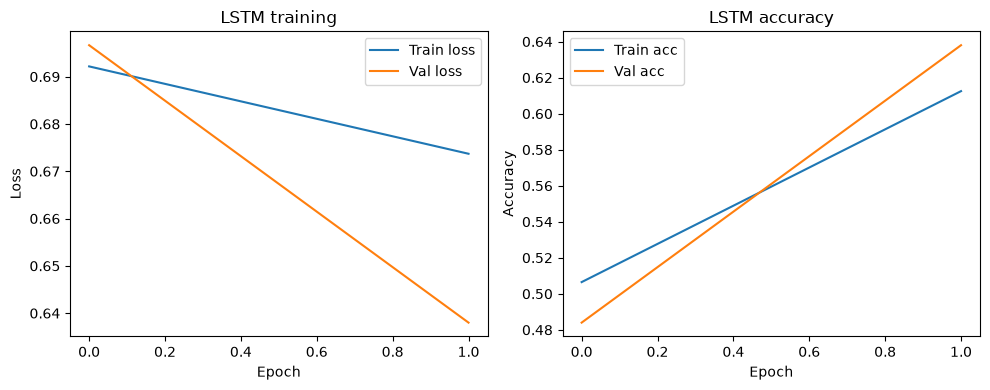

Test accuracy: 0.6380


In [4]:
# WHAT: plot the LSTM's training curves and report test accuracy.
# WHY: the curves show whether the network is still improving or starting to overfit.
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("LSTM training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("LSTM accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

## 🌍 Real-World Worked Example — Stock Trend Prediction (and an Honesty Check)

**Industry context:** Hedge funds and trading platforms really do run LSTMs on price
sequences — and most claimed "prediction accuracy" evaporates once it is compared
against the right baseline.

We train an LSTM to predict whether a **synthetic stock price** goes up or down the
next day. The data is a **random walk with upward drift**: each day's move is drawn
independently of the past, so the *only* learnable signal is the drift itself. That
makes the honest benchmark the **base rate** (always predict the majority direction),
not the 50% coin flip that "stock prediction" demos usually quote. Watch how the
comparison changes the story.

LSTM direction accuracy:          59.2%
Always-predict-majority baseline: 59.2%  (test set is 59.2% 'up' days)
LSTM edge over the honest baseline: +0.0 points

By construction, each day's move is INDEPENDENT of the past 20 days,
so no model can consistently beat the base rate on this data — any gap
either way is test-set noise (~+/-3.6 points at n≈196).
Lesson: always compare a 'market predictor' to the base rate, not to 50%.


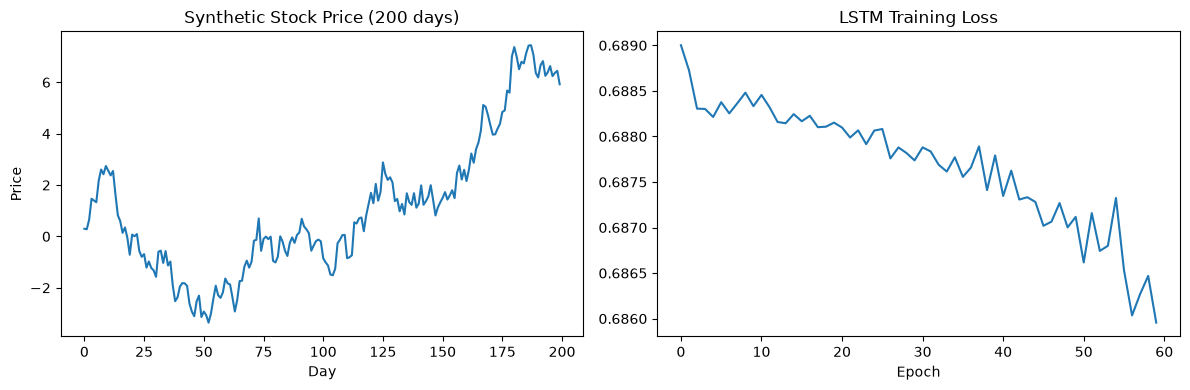

In [5]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate a stock-like price series: a RANDOM WALK with drift ─────────
# Each daily step is independent N(+0.05, 0.5) — the past 20 days carry NO
# information about tomorrow beyond the constant drift.
np.random.seed(42)
torch.manual_seed(0)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ──────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# ── Honest evaluation: compare against the base rate, not against 50% ─────
model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
p_up = Yte.float().mean().item()
base = max(p_up, 1.0 - p_up)   # always predict the majority direction

print(f"LSTM direction accuracy:          {acc*100:.1f}%")
print(f"Always-predict-majority baseline: {base*100:.1f}%  (test set is {p_up*100:.1f}% 'up' days)")
print(f"LSTM edge over the honest baseline: {(acc-base)*100:+.1f} points")
print()
print("By construction, each day's move is INDEPENDENT of the past 20 days,")
print("so no model can consistently beat the base rate on this data — any gap")
print("either way is test-set noise (~+/-3.6 points at n≈196).")
print("Lesson: always compare a 'market predictor' to the base rate, not to 50%.")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Replace the LSTM with a GRU layer (same number of units), retrain for 1 epoch, and compare the loss curve with the LSTM run.

---

## ✅ Summary

**What you did:** Built an LSTM for sequence classification (IMDB sentiment), trained it, and plotted loss/accuracy.

**In real life you'd also:** Try GRU, bidirectional LSTM, and tune units and embedding size.

**The main idea:** LSTM uses gates to control memory and helps train on longer sequences; it often outperforms SimpleRNN on long-range dependencies.

**Next:** `04_transformer_attention` introduces attention and transformers; `06_gpt_text_generation` covers text generation.

## 🔭 State of the field (2026)

For language, LSTMs and GRUs were replaced in production by transformers years ago. What changed in 2024 is that the gates themselves came back under revision rather than being retired. xLSTM (arXiv 2405.04517) replaces the LSTM's sigmoid gating with *exponential* gating plus a normaliser state, and its mLSTM variant drops the hidden-to-hidden recurrence for a matrix memory that parallelises — scaled to billions of parameters and reported competitive with transformers and state-space models. *Were RNNs All We Needed?* (arXiv 2410.01201) goes the other way and deletes structure: minimal LSTM/GRU variants whose gates no longer depend on the previous hidden state, which makes training fully parallel.

**Why the classic gates are still the right thing to learn.** Both of those papers are *diffs* against the forget/input/output equations in this notebook — you cannot evaluate either claim without them. The gating idea itself also outlived the architecture: gated residual paths and selective state updates appear throughout modern sequence models. And constant memory per step, the property that makes recurrence attractive again for long context, is a property of the cell state you are studying here.


## 📚 References

1. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
2. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation* (GRU). EMNLP. https://arxiv.org/abs/1406.1078
3. Greff, K. et al. (2017). *LSTM: A Search Space Odyssey*. IEEE Transactions on Neural Networks and Learning Systems. https://arxiv.org/abs/1503.04069

**Recent work (2024–2026)**

4. Beck, M. et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. https://arxiv.org/abs/2405.04517 — the 2024 rebuild of the exact gates in this notebook: exponential gating with a normaliser state (sLSTM) and a matrix memory that parallelises (mLSTM).
5. Feng, L., Tung, F., Ahmed, M. O., Bengio, Y. & Hajimirsadeghi, H. (2024). *Were RNNs All We Needed?* arXiv. https://arxiv.org/abs/2410.01201 — strips the gates' dependence on the previous hidden state so training parallelises, with fewer parameters than the LSTM/GRU you just built.
